In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import catboost as cb

import sys
sys.path.insert(0, '../..')

from sn_clf.scripts.utils import get_sn_label_from_akb, load_features, download_akb_json, plot_config, get_art_label_from_akb, convert_to_onnx

plot_config()

In [2]:
feature_names = '../../dr23-features/feature_snad_clf_r_100.name'
with open(feature_names) as f:
    names = f.read().split()

train_data = pd.read_csv('../data/train_data_big.csv')

Scores for Random Forest Classifier:
accuracy = 0.986 ± 0.002
f1 = 0.804 ± 0.034
roc_auc = 0.977 ± 0.011
RF trained (with cross-validation) in 1 m


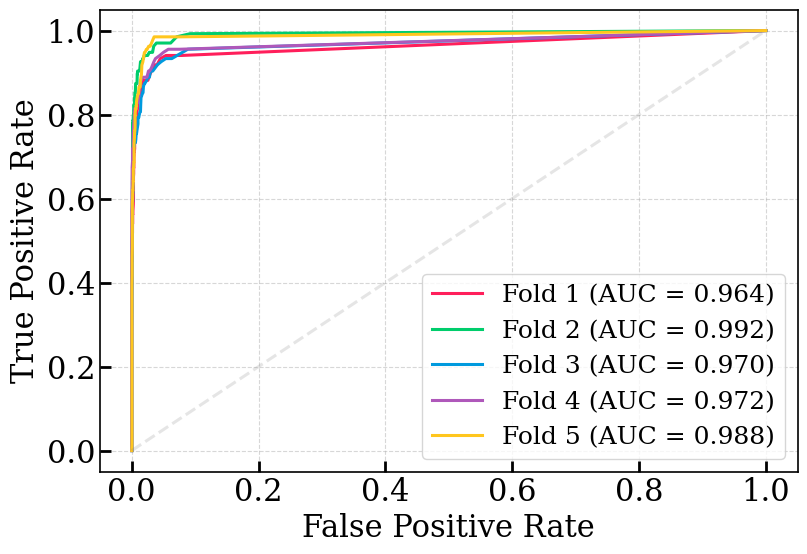

In [3]:
col = [u'#FF1F5B', u'#00CD6C', u'#009ADE', u'#AF58BA', u'#FFC61E']

# Исходные данные
X = train_data[names].values
y = train_data['is_sn'].values

random_seed = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Для хранения метрик
scores = {'accuracy': [], 'f1': [], 'roc_auc': []}
models = []

plt.figure(figsize=(9, 6))
t = time.monotonic()

for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = RandomForestClassifier(
        random_state=random_seed,
        class_weight={0: 1, 1: 1e3}
    )
    model.fit(X_train, y_train)
    models.append(model)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    scores['accuracy'].append(acc)
    scores['f1'].append(f1)
    scores['roc_auc'].append(roc_auc)
    
    # ROC кривая
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr,
             label=f'Fold {i+1} (AUC = {roc_auc:.3f})',
             color=col[i])

# Оформление графика
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig('../figures/clf_roc_curves.pdf', dpi=400, format='pdf', bbox_inches="tight")

# Вывод усреднённых метрик
print('Scores for Random Forest Classifier:')
for metric in scores:
    mean = np.mean(scores[metric])
    std = np.std(scores[metric])
    print(f'{metric} = {mean:.3f} ± {std:.3f}')

t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')

In [3]:

# Исходные данные
X = train_data[names].values
y = train_data['is_sn'].values

random_seed = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# Для хранения метрик
scores = {'accuracy': [], 'f1': [], 'roc_auc': []}

# Для усреднения ROC
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 300)


t = time.monotonic()

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = RandomForestClassifier(
        random_state=random_seed,
        class_weight={0: 1, 1: 1e3}
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Метрики
    scores['accuracy'].append(accuracy_score(y_test, y_pred))
    scores['f1'].append(f1_score(y_test, y_pred))
    scores['roc_auc'].append(roc_auc_score(y_test, y_prob))

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Интерполяция TPR на единый FPR
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

# Средняя и std ROC
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tpr_upper = mean_tpr + std_tpr
tpr_lower = mean_tpr - std_tpr

Scores for Random Forest Classifier:
accuracy = 0.986 ± 0.002
f1 = 0.804 ± 0.034
roc_auc = 0.977 ± 0.011
RF trained (with cross-validation) in 14161 m


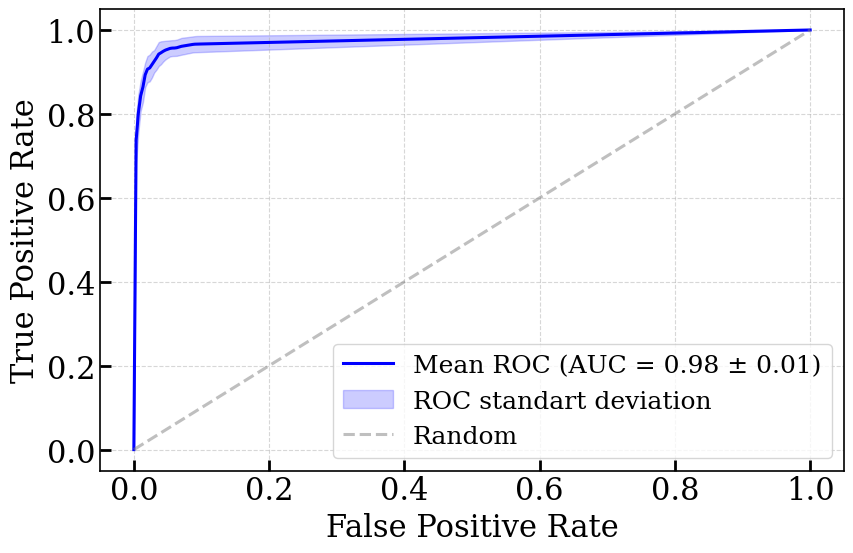

In [14]:
col_mean = '#009ADE'   # основной цвет средней кривой
col_std  = '#AF58BA'   # цвет коридора

plt.figure(figsize=(9, 6))
plt.plot(mean_fpr, mean_tpr, color='blue',
         label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})")

plt.fill_between(mean_fpr, tpr_lower, tpr_upper,
                 color='blue', alpha=0.2,
                 label='ROC standart deviation')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.savefig('../figures/clf_roc_mean_with_std.pdf', dpi=400, format='pdf')

# Печать метрик
print('Scores for Random Forest Classifier:')
for metric in scores:
    print(f'{metric} = {np.mean(scores[metric]):.3f} ± {np.std(scores[metric]):.3f}')

t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')

In [5]:
#model_name = 'rf_classweight'
#convert_to_onnx(clf, len(names), name=model_name)

/tmp/ipykernel_2141/453930361.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


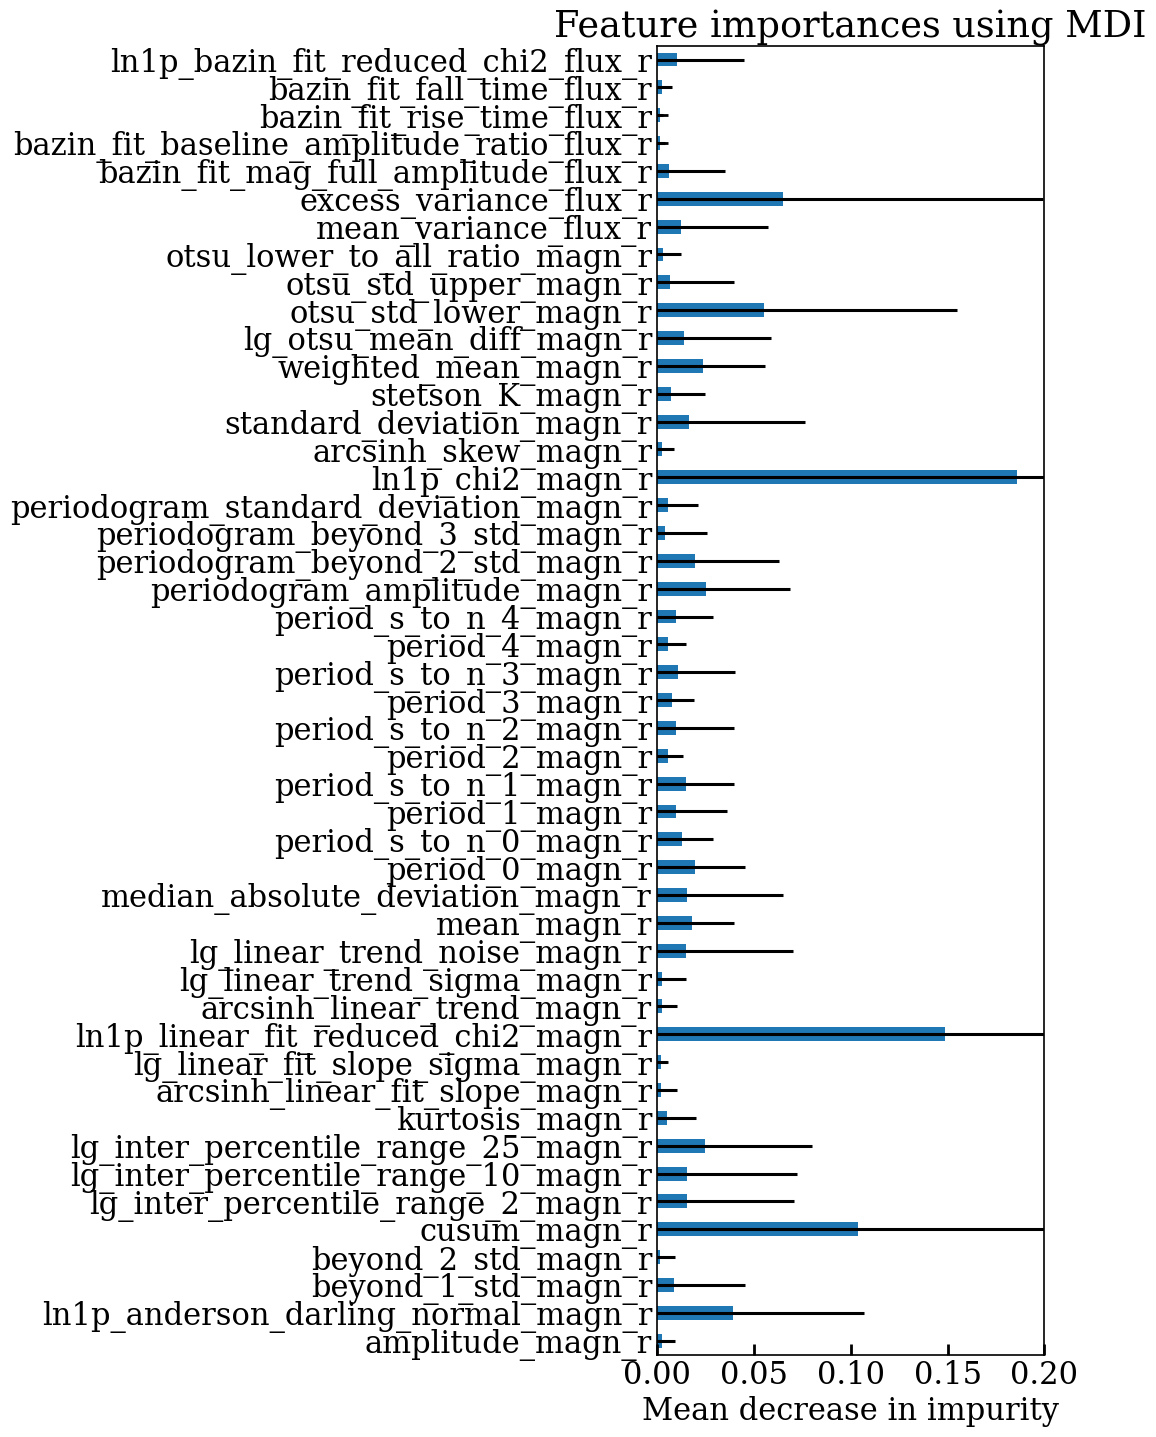

In [6]:
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=names)


fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

#plt.savefig('feature_imp.png', bbox_inches='tight')